# 高效 Attention：O(N²) 问题的两条路线

> 前面几节里，Attention 都是「每个 token 看到所有 token」——序列长度翻倍，计算量变四倍。长上下文（22 节）、KV Cache 压缩（29 节）都在缓解这个问题，但都没动 Attention 本身的 $O(N^2)$ 结构。
>
> 这一节直面这个结构。解决 $O(N^2)$ 有两条正交路线：**Linear Attention** 换计算顺序，保留所有 query-key 对但每个 $O(1)$ 算；**Sparse Attention** 保留 softmax，但只算一部分 query-key 对。两条路线各有代价，工业实践（MiniMax-01、Kimi K2、Jamba）越来越多地走 hybrid 路线——把两者混起来用。

Attention 的核心计算是 $Q K^T V$：三个矩阵相乘，形状分别是 $[N, d]$、$[d, N]$、$[N, d]$。$Q K^T$ 得到 $[N, N]$ 的注意力矩阵——这就是 $O(N^2)$ 的根源。N=4096 时还好，N=131072（GPT-4 的 128K 上下文）时，光是这个矩阵就要 64 GB 显存（FP32）。

两条路线对应两种"砍这个 $N^2$"的思路：

- **Linear Attention**：注意到 $Q K^T V$ 可以结合律重写成 $Q (K^T V)$。中间矩阵变成 $[d, d]$，复杂度 $O(N \cdot d^2)$。对 N 来说是线性的
- **Sparse Attention**：观察到注意力矩阵本来就稀疏（大部分权重接近 0），干脆只算那些重要的 query-key 对，复杂度 $O(N \cdot k)$，k 是每个 query 关心的 key 数量

两者都让复杂度对 N 变成线性，但走了完全不同的路。下面先看 Linear Attention，再看 Sparse Attention，最后对比。

## 1. $O(N^2)$ 瓶颈：手算 attention 计算量

先把账算清楚。给定序列长度 $N$ 和 head 维度 $d$，标准 attention 的核心计算 $	ext{softmax}(Q K^T) V$ 涉及三个矩阵乘法：

```
Q × K^T  → [N, N] 矩阵，FLOPs = N × N × d = N²d
softmax  → 不算 FLOPs（按元素操作）
attn × V → [N, d] 矩阵，FLOPs = N × N × d = N²d
总 FLOPs ≈ 2 × N² × d
```

中间结果 $Q K^T$ 是个 $N 	imes N$ 矩阵，存储和计算都按 $N^2$ 增长。下面用一个具体数字感受这个增长有多快。

In [1]:
# Softmax attention 的 O(N²) 瓶颈：手算几个具体数字

d = 128  # head_dim

print(f"head_dim = {d}")
print(f"{'序列长度 N':<15} {'QK^T 元素数':<20} {'FP16 显存':<15} {'相对 4K'}")
print("-" * 60)
base_elems = None
for N in [4096, 8192, 32768, 131072, 524288]:
    elems = N * N
    bytes_ = elems * 2  # FP16
    gb = bytes_ / (1024**3)
    if base_elems is None:
        base_elems = elems
    label = f"{N//1024}K" if N >= 1024 else str(N)
    print(f"{label:<15} {elems:<20,} {gb:<15.2f} {elems/base_elems:.0f}×")

print()
print("关键观察：从 4K 到 512K，序列长度增加 128 倍，attention 中间结果增加 16384 倍")
print("这就是为什么长上下文不能用纯 softmax attention——单层中间结果就几百 GB")

head_dim = 128
序列长度 N          QK^T 元素数             FP16 显存         相对 4K
------------------------------------------------------------
4K              16,777,216           0.03            1×
8K              67,108,864           0.12            4×
32K             1,073,741,824        2.00            64×
128K            17,179,869,184       32.00           1024×
512K            274,877,906,944      512.00          16384×

关键观察：从 4K 到 512K，序列长度增加 128 倍，attention 中间结果增加 16384 倍
这就是为什么长上下文不能用纯 softmax attention——单层中间结果就几百 GB


## 2. 路线 A：Linear Attention 与 SSM（换计算顺序）

Linear Attention 这一节走「换计算方式」这条路——保留所有 query-key 对，但用数学技巧把 $O(N^2)$ 改成 $O(N \cdot d^2)$。这条路线在数学上和状态空间模型（SSM）天然接近：两者都把 attention 写成递推形式，每步只维护一个固定大小的隐状态。下面从 Linear Attention 的核心思想开始，逐步走到 Mamba、Mamba-2、Lightning Attention，最后看 hybrid 架构如何把它们组合进生产模型。

### 2.1 Linear Attention 的核心思想：结合律换计算顺序

线性注意力的核心观察：标准 attention 写成 $	ext{softmax}(Q K^T) V$，括号先算 $Q K^T$（得到 $N 	imes N$ 矩阵），再乘 $V$。如果把 softmax 换成一个可以分离的形式 $\phi(Q) \phi(K)^T$，括号可以换位置：

$$
\underbrace{(\phi(Q) \phi(K)^T)}_{N \times N} V \quad \Rightarrow \quad \phi(Q) \underbrace{(\phi(K)^T V)}_{d \times d}
$$

新的计算顺序：先算 $\phi(K)^T V$（一个 $d \times d$ 的小矩阵），再左乘 $\phi(Q)$。

| 计算顺序 | 中间结果大小 | 总 FLOPs |
|:---|:---|:---|
| 标准 $(Q K^T) V$ | $N \times N$ | $O(N^2 d)$ |
| Linear $Q (K^T V)$ | $d \times d$ | $O(N d^2)$ |

当 $d \ll N$ 时（比如 $d=128, N=32K$），从 $O(N^2 d)$ 到 $O(N d^2)$ 是巨大的节省。

但 softmax 不能写成 $\phi(Q) \phi(K)^T$ 的可分离形式——它对每一行做归一化，跨了所有 key。Linear attention 的做法是把 softmax 换成其他 kernel 函数，常用的有：
- $\phi(x) = \text{elu}(x) + 1$（最早由 Katharopoulos 等人 2020 提出）
- $\phi(x) = \text{ReLU}(x)$（更简单但效果稍差）
- 还有基于随机特征（random features）的近似

下面用一个 4 token 的小例子手算一遍，对比 softmax attention 和 linear attention 的输出。

In [2]:
# 手算对比：softmax attention vs linear attention（4 token 小例子）

import torch
import torch.nn.functional as F

torch.manual_seed(42)

N = 4   # 4 个 token
d = 3   # head_dim = 3

Q = torch.randn(N, d)
K = torch.randn(N, d)
V = torch.randn(N, d)

print("Q =\n", Q)
print("\nK =\n", K)
print("\nV =\n", V)

# === 标准 softmax attention ===
scores = Q @ K.T / (d ** 0.5)
attn_weights = F.softmax(scores, dim=-1)
out_softmax = attn_weights @ V
print("\n=== Softmax Attention ===")
print(f"QK^T / sqrt(d) =\n{scores}")
print(f"\nsoftmax(QK^T) =\n{attn_weights}")
print(f"\n输出 =\n{out_softmax}")

# === Linear attention ===
# φ(x) = elu(x) + 1
phi_Q = F.elu(Q) + 1
phi_K = F.elu(K) + 1

# 标准写法（O(N²d)）：先算 φ(Q)φ(K)^T，再乘 V
linear_scores_naive = phi_Q @ phi_K.T
# 归一化：每行除以该行所有分母之和
normalizer = linear_scores_naive.sum(dim=-1, keepdim=True)
out_linear_naive = (linear_scores_naive @ V) / normalizer

print("\n=== Linear Attention ===")
print(f"φ(Q) = elu(Q)+1 =\n{phi_Q}")
print(f"\nφ(K) = elu(K)+1 =\n{phi_K}")
print(f"\nφ(Q)φ(K)^T =\n{linear_scores_naive}")
print(f"\n输出 =\n{out_linear_naive}")

# === Linear attention 的 O(Nd²) 写法 ===
# 利用结合律：φ(Q) @ (φ(K)^T @ V)
KV = phi_K.T @ V  # [d, d] 小矩阵
out_linear_fast = phi_Q @ KV / normalizer
print(f"\n=== Linear Attention（结合律换顺序）===")
print(f"φ(K)^T @ V =\n{KV}")
print(f"\n输出（应该和上面相同）=\n{out_linear_fast}")
print(f"\n两次结果是否一致: {torch.allclose(out_linear_naive, out_linear_fast, atol=1e-6)}")

Q =
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617],
        [ 0.2674,  0.5349,  0.8094]])

K =
 tensor([[ 1.1103, -1.6898, -0.9890],
        [ 0.9580,  1.3221,  0.8172],
        [-0.7658, -0.7506,  1.3525],
        [ 0.6863, -0.3278,  0.7950]])

V =
 tensor([[ 0.2815,  0.0562,  0.5227],
        [-0.2384, -0.0499,  0.5263],
        [-0.0085,  0.7291,  0.1331],
        [ 0.8640, -1.0157, -0.8887]])

=== Softmax Attention ===
QK^T / sqrt(d) =
tensor([[-0.0437,  0.3952, -0.0216,  0.2167],
        [ 1.3495, -0.8176,  0.2393,  0.2182],
        [ 1.7744,  0.9521, -0.3394,  1.2076],
        [-0.8126,  0.9380,  0.2820,  0.3762]])

softmax(QK^T) =
tensor([[0.2053, 0.3184, 0.2099, 0.2664],
        [0.5661, 0.0648, 0.1865, 0.1826],
        [0.4700, 0.2065, 0.0568, 0.2667],
        [0.0767, 0.4419, 0.2293, 0.2520]])

输出 =
tensor([[ 0.2103, -0.1219,  0.0661],
        [ 0.3001, -0.0210,  0.1925],
        [ 0.3130, -0.2134,  0.1250],
    

### 2.2 Linear Attention 的代价：失去「尖锐性」

Linear attention 在数学上是 softmax attention 的近似。**它们的结果不完全一样**——下面看为什么。

Softmax 的一个关键性质是**尖锐性（sharpness）**：当某个 query 和某个 key 的点积远大于其他，softmax 会把几乎所有权重给到那个 key。比如：

```
softmax([10, 1, 1, 1]) ≈ [0.999, 0.0003, 0.0003, 0.0003]  ← 极尖
```

这种「近乎 one-hot」的权重让 attention 能精准地把某个 token 的信息聚合到 query 上——这是 retrieval、copy 这类任务的关键能力。

Linear attention 没有这种尖锐性。$\phi(Q) \phi(K)^T$ 是逐元素非线性的乘积，最大值和最小值的差距远不如 softmax 大。结果是权重分布比较平坦，没法对某个特定 token 给极高权重。下面的代码量化对比两者。

Query ≈ Key[0]，理想权重应该几乎全给 position 0

Position   Softmax 权重           Linear 权重           
--------------------------------------------------
0          0.6952               0.1411              
1          0.0509               0.1410              
2          0.0278               0.1226              
3          0.0278               0.1408              
4          0.0212               0.1220              
5          0.0052               0.0925              
6          0.0085               0.0937              
7          0.1635               0.1463              

关键观察：
  Softmax 把 69.5% 的权重给 position 0 → 近乎 one-hot
  Linear 只把 14.1% 的权重给 position 0 → 分布平坦
  → Linear attention 在「精准 retrieval」上天然弱


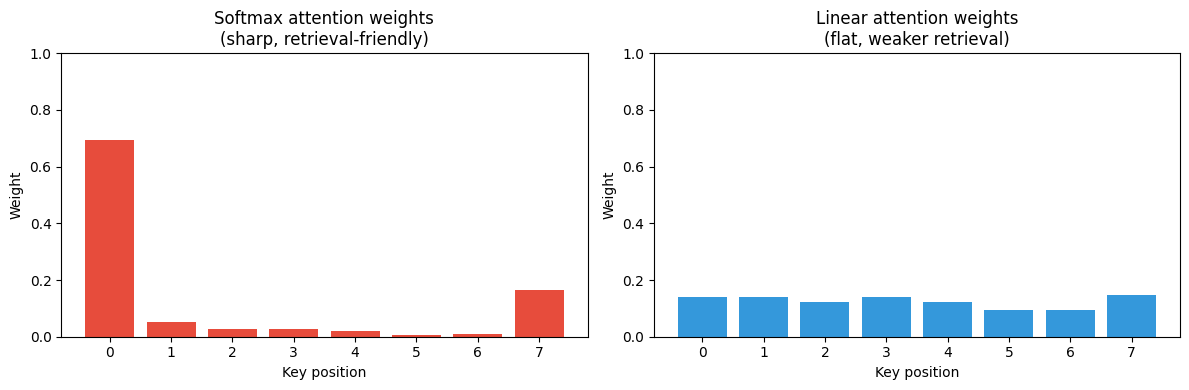

In [3]:
# Sharpness 对比：softmax vs linear attention

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 构造一个场景：query 与 key[0] 非常相似，与其他 key 不相似
torch.manual_seed(0)
N, d = 8, 16

# query 与 K[0] 几乎相同，与其他 K 正交
K = torch.randn(N, d)
Q = K[0:1].clone() + 0.01 * torch.randn(1, d)  # Q ≈ K[0]
V = torch.eye(N)  # V 是单位矩阵，这样输出就是 attention 权重本身

# Softmax attention
scores_softmax = Q @ K.T / (d ** 0.5)
weights_softmax = F.softmax(scores_softmax, dim=-1)

# Linear attention
phi_Q = F.elu(Q) + 1
phi_K = F.elu(K) + 1
linear_scores = phi_Q @ phi_K.T
weights_linear = linear_scores / linear_scores.sum(dim=-1, keepdim=True)

print(f"Query ≈ Key[0]，理想权重应该几乎全给 position 0")
print()
print(f"{'Position':<10} {'Softmax 权重':<20} {'Linear 权重':<20}")
print("-" * 50)
for i in range(N):
    print(f"{i:<10} {weights_softmax[0, i].item():<20.4f} {weights_linear[0, i].item():<20.4f}")

print()
print(f"关键观察：")
print(f"  Softmax 把 {weights_softmax[0, 0].item()*100:.1f}% 的权重给 position 0 → 近乎 one-hot")
print(f"  Linear 只把 {weights_linear[0, 0].item()*100:.1f}% 的权重给 position 0 → 分布平坦")
print(f"  → Linear attention 在「精准 retrieval」上天然弱")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), weights_softmax[0].numpy(), color='#e74c3c')
axes[0].set_title('Softmax attention weights\n(sharp, retrieval-friendly)')
axes[0].set_xlabel('Key position')
axes[0].set_ylabel('Weight')
axes[0].set_ylim(0, 1)

axes[1].bar(range(N), weights_linear[0].numpy(), color='#3498db')
axes[1].set_title('Linear attention weights\n(flat, weaker retrieval)')
axes[1].set_xlabel('Key position')
axes[1].set_ylabel('Weight')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 2.3 从 Linear Attention 到 SSM：递推视角

Linear Attention 的核心思想在 2.1 节里写成两种等价形式：$(Q K^T) V$ 的向量化写法，和利用结合律换顺序的 $Q (K^T V)$。其实还有第三种写法——**递推形式**，它把线性注意力从「看整段序列」改写成「逐 token 更新隐状态」。

具体地，把累积的 $\phi(K)^T V$ 看作一个隐状态 $S_t$：

$$
S_t = S_{t-1} + \phi(k_t) v_t^T, \quad o_t = \phi(q_t) S_t
$$

每来一个 token，先把它的 $\phi(k_t) v_t^T$ 累加进状态 $S_t$，再用 $\phi(q_t)$ 去查询当前状态。这个递推视角让 Linear Attention 和 SSM 在数学上对齐：两者都维护一个固定大小的状态，每步只做小矩阵乘法。区别在于 Linear Attention 的「状态转移」是恒等累加，而 SSM 用一个学出来的矩阵 $A$ 控制状态如何演化——这正是下一节的内容。

In [4]:
# Linear Attention 的递推形式（causal 版本）

import torch
import torch.nn.functional as F

torch.manual_seed(42)

N, d = 5, 3
Q = torch.randn(N, d)
K = torch.randn(N, d)
V = torch.randn(N, d)

phi_Q = F.elu(Q) + 1
phi_K = F.elu(K) + 1

# 递推形式（causal）：S_t = S_{t-1} + φ(k_t) v_t^T，o_t = φ(q_t) S_t
# 每个 token 只看自己之前的 token
S = torch.zeros(d, d)
out_rec = []
print("=== Linear Attention 递推展开（causal）===")
for t in range(N):
    S = S + phi_K[t].unsqueeze(1) @ V[t].unsqueeze(0)  # 累积到当前 t
    o_t = phi_Q[t] @ S
    out_rec.append(o_t)
    print(f"t={t}: 累积后 S 范数 = {S.norm().item():.3f}, o_t[0] = {o_t[0].item():.3f}")
out_rec = torch.stack(out_rec)

# 对比：用 causal mask 的向量化形式（每个 query 只看前面 key）
scores = phi_Q @ phi_K.T  # [N, N]
# causal mask：上三角（j > i）置 0
causal_mask = torch.tril(torch.ones(N, N))
scores_causal = scores * causal_mask
normalizer = scores_causal.sum(dim=-1, keepdim=True).clamp(min=1e-6)
out_vec_causal = (scores_causal @ V) / normalizer

# 不归一化的递推 vs 不归一化的向量化（直接比 φ(q)S 形式）
out_vec_unnorm = (scores_causal @ V)  # [N, d]

print()
print(f"递推输出 vs 向量化（causal）是否一致: "
      f"{torch.allclose(out_rec, out_vec_unnorm, atol=1e-6)}")
print()
print("关键观察：递推形式天然是 causal（每个 token 只看历史）")
print("把递推展开就是 causal Linear Attention，复杂度每步 O(d²)，总 O(Nd²)")

=== Linear Attention 递推展开（causal）===
t=0: 累积后 S 范数 = 2.623, o_t[0] = -0.064
t=1: 累积后 S 范数 = 3.367, o_t[0] = 2.274
t=2: 累积后 S 范数 = 4.088, o_t[0] = 5.649
t=3: 累积后 S 范数 = 5.873, o_t[0] = 11.653
t=4: 累积后 S 范数 = 4.136, o_t[0] = 3.940

递推输出 vs 向量化（causal）是否一致: True

关键观察：递推形式天然是 causal（每个 token 只看历史）
把递推展开就是 causal Linear Attention，复杂度每步 O(d²)，总 O(Nd²)


### 2.4 SSM 基础：离散状态方程

状态空间模型（State Space Model, SSM）从控制理论发展来，把序列建模写成「状态 + 输入 + 输出」的形式。离散时间版本的方程如下：

$$
x_t = A x_{t-1} + B u_t, \quad y_t = C x_t
$$

其中 $u_t \in \mathbb{R}^1$ 是当前输入信号（一维标量，类似一个 token 的某个特征通道），$x_t \in \mathbb{R}^N$ 是 N 维隐状态（类比 LSTM 的 cell state），$y_t$ 是输出。$A \in \mathbb{R}^{N \times N}$ 是状态转移矩阵，$B \in \mathbb{R}^{N \times 1}$ 把输入投影到状态，$C \in \mathbb{R}^{1 \times N}$ 把状态投影回输出。

和 Linear Attention 对比：Linear Attention 的递推是 $S_t = S_{t-1} + \phi(k_t) v_t^T$，相当于 $A = I$（恒等累加）、$B = \phi(k_t)$、$C = \phi(q_t)$，并且 $B, C$ 随时间变化。SSM 的关键不同是引入一个**学出来的、固定的** $A$ 矩阵，让状态按某个动力学演化，而不是简单累加。

$A$ 的作用可以从两个极端看清楚：

- $A = I$ 时，状态只增不减——长期记忆但容易爆炸
- $A = 0$ 时，状态每步清零——只看当前输入
- $A$ 的特征值小于 1 时，状态指数衰减——只保留近期信息，相当于「记忆有半衰期」

实际 SSM 训练时把 $A$ 初始化为某种特殊结构（比如 HiPPO 矩阵），让记忆在长距离上保持稳定。下面用一个 4 步的手算例子看清楚递推过程。

In [5]:
# 手算 SSM：4 步递推，观察 A 对记忆的影响

import torch

# 极小配置：2 维状态，标量输入
A = torch.tensor([[0.5, 0.0],
                  [0.0, 0.9]])  # 对角 A，两个通道衰减速率不同
B = torch.tensor([[1.0], [1.0]])
C = torch.tensor([[1.0, 1.0]])

# 输入序列：u = [3, 0, 0, 0]，观察 t=0 写入的 3 如何衰减
u_seq = [3.0, 0.0, 0.0, 0.0]

x = torch.zeros(2, 1)  # 初始隐状态
print("=== 4 步 SSM 手算 ===")
print(f"A = diag(0.5, 0.9)，B = [1, 1]^T，C = [1, 1]")
print(f"输入 u = {u_seq}")
print()
for t, u in enumerate(u_seq):
    x = A @ x + B * u           # 状态更新
    y = (C @ x).item()          # 输出
    print(f"t={t}: u={u}")
    print(f"      x = [{x[0,0].item():.4f}, {x[1,0].item():.4f}]")
    print(f"      y = {y:.4f}")
    print()

print("关键观察：")
print("  - 通道 0（衰减 0.5）：t=0 写入 3，经过 3 次衰减后剩 0.375 → 短期记忆")
print("  - 通道 1（衰减 0.9）：t=0 写入 3，经过 3 次衰减后剩 2.187 → 长期记忆")
print("  - A 的不同特征值让 SSM 同时维护多个时间尺度的信息")

=== 4 步 SSM 手算 ===
A = diag(0.5, 0.9)，B = [1, 1]^T，C = [1, 1]
输入 u = [3.0, 0.0, 0.0, 0.0]

t=0: u=3.0
      x = [3.0000, 3.0000]
      y = 6.0000

t=1: u=0.0
      x = [1.5000, 2.7000]
      y = 4.2000

t=2: u=0.0
      x = [0.7500, 2.4300]
      y = 3.1800

t=3: u=0.0
      x = [0.3750, 2.1870]
      y = 2.5620

关键观察：
  - 通道 0（衰减 0.5）：t=0 写入 3，经过 3 次衰减后剩 0.375 → 短期记忆
  - 通道 1（衰减 0.9）：t=0 写入 3，经过 3 次衰减后剩 2.187 → 长期记忆
  - A 的不同特征值让 SSM 同时维护多个时间尺度的信息


### 2.5 Mamba 的关键创新：selective SSM

普通 SSM 有一个结构性缺陷：$A, B, C$ 是固定参数，对所有时间步、所有输入都用同一套转移规则。这导致模型没办法根据输入内容**选择性记忆或遗忘**——遇到需要"记住这个特定 token"的任务时力不从心。

Mamba（2023）的核心创新是把 $B, C$ 和离散化步长 $\Delta$ 都变成输入的函数：

$$
B_k = f_B(u_k), \quad C_k = f_C(u_k), \quad \Delta_k = f_\Delta(u_k)
$$

离散化后的状态更新变成 $x_k = \bar{A}_k x_{k-1} + \bar{B}_k u_k$，其中 $\bar{A}_k, \bar{B}_k$ 由 $\Delta_k$ 决定（通过零阶保持离散化 $\bar{A} = \exp(\Delta A)$，$\bar{B} = (\Delta A)^{-1}(\exp(\Delta A) - I) \Delta B$）。三个输入相关的量分别承担不同语义：

- **$\Delta_k$ 控制时间尺度**：决定"这一步的状态更新力度有多大"。$\Delta_k$ 大时新输入主导（覆盖旧记忆），小时保留历史。等价于 LSTM 的遗忘门
- **$B_k$ 控制写入什么**：决定当前输入如何被投影进状态空间，等价于输入门
- **$C_k$ 控制读什么**：决定从状态空间如何读出，等价于输出门

$A$ 仍然是学出来的固定矩阵，但通过 $\Delta_k$ 的调制，实际有效转移 $\bar{A}_k$ 也会随输入变化。这种 input-dependent 的机制让 SSM 第一次具备和 attention 接近的「按内容路由」能力。下面用 mini PyTorch demo 展示 $B_k, C_k, \Delta_k$ 如何随输入变化。

In [6]:
# Mamba selective SSM：B/C/Δ 是输入的函数

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

d_model = 8       # 输入维度
d_state = 4       # 隐状态维度 N

# 投影函数：把输入 u_k 映射到 B_k, C_k, Δ_k
proj_B = nn.Linear(d_model, d_state)
proj_C = nn.Linear(d_model, d_state)
proj_Delta = nn.Linear(d_model, 1)  # 每个通道一个标量 Δ

# 固定的 A 矩阵（实际中由可学参数初始化为对角形式）
A_log = torch.randn(d_state) * 0.5  # 用 log 参数化保证 A 为负

def selective_ssm_forward(u_seq):
    """简化版 selective SSM 前向，返回每个时间步的输出"""
    N = u_seq.shape[0]
    # 输入相关的 B, C, Δ
    B_seq = proj_B(u_seq)        # [N, d_state]
    C_seq = proj_C(u_seq)        # [N, d_state]
    Delta_seq = F.softplus(proj_Delta(u_seq)).squeeze(-1)  # [N]，保证 > 0

    A = -torch.exp(A_log)        # A < 0，保证稳定
    x = torch.zeros(d_state)
    outputs = []

    for t in range(N):
        # 离散化（零阶保持，标量化处理 Δ）
        d_t = Delta_seq[t]
        A_bar = torch.exp(A * d_t)             # 对角 A 下，exp(ΔA) 是逐元素
        B_bar = (d_t) * B_seq[t]               # 简化：忽略 (ΔA)^{-1}(exp(ΔA)-1) 的精确项
        # 状态更新
        x = A_bar * x + B_bar * u_seq[t, 0]    # 用 u 的第一个通道作为标量输入
        # 输出
        y = C_seq[t] @ x
        outputs.append(y.item())

    return outputs, Delta_seq, B_seq, C_seq

# 喂一段序列，观察 Δ_k 在不同 token 上的变化
u_seq = torch.randn(6, d_model)
outputs, Delta, B, C = selective_ssm_forward(u_seq)

print("=== Selective SSM：B/C/Δ 随输入变化 ===")
print(f"输入序列 shape: {u_seq.shape}")
print()
print(f"每个 token 的 Δ_k（时间尺度）:")
for t in range(u_seq.shape[0]):
    print(f"  t={t}: Δ={Delta[t].item():.4f}  "
          f"B={B[t].tolist()[:3]}...  C={C[t].tolist()[:3]}...")

print()
print("关键观察：")
print("  - Δ_k 每步不同 → 模型可以根据内容决定何时重写状态")
print("  - B_k 控制写入方向 → 当前 token 要如何编码进状态")
print("  - C_k 控制读出方向 → 当前 token 要从状态读什么")
print("  - 这种 input-dependent 行为是 Mamba 比 vanilla SSM 强的根本原因")

=== Selective SSM：B/C/Δ 随输入变化 ===
输入序列 shape: torch.Size([6, 8])

每个 token 的 Δ_k（时间尺度）:
  t=0: Δ=0.8830  B=[-0.2713034152984619, -0.3910537362098694, 0.09570382535457611]...  C=[0.5286576747894287, 1.1092441082000732, -0.7380498647689819]...
  t=1: Δ=0.7547  B=[-0.1695612519979477, 0.1478886902332306, -0.5377374887466431]...  C=[0.6945362091064453, 0.9450764656066895, -0.08935871720314026]...
  t=2: Δ=0.6618  B=[-0.04303900897502899, 0.6395689249038696, -0.36104580760002136]...  C=[0.11200087517499924, -0.2267950177192688, 0.6489959955215454]...
  t=3: Δ=0.7022  B=[-0.7607427835464478, 0.04466179013252258, -0.7721929550170898]...  C=[0.5279473066329956, 0.2611466944217682, 0.04918026924133301]...
  t=4: Δ=0.3746  B=[-0.09264937043190002, 0.05585569143295288, -0.025594577193260193]...  C=[-0.23855066299438477, -0.4601873755455017, -0.3486384451389313]...
  t=5: Δ=0.6492  B=[-0.001425430178642273, 0.06072363257408142, -0.08381308615207672]...  C=[0.2775786519050598, -0.08450311422348022,

### 2.6 为什么普通 SSM 不能做选择性任务

selective 机制到底带来什么本质提升？Mamba 论文里有一个经典 benchmark：**selective copy task**。给定输入序列 `[3, 1, 4, 1, 5]`，要求模型在输出阶段按出现顺序重新输出所有 `1`（或者其他规则下选择的子集）。这个任务的关键是模型必须**根据内容**区分哪些 token 该被记住、哪些该被忽略——而不是按固定位置（前 3 个、后 5 个）来处理。

普通 SSM（固定 $A/B/C$）无法做这个任务：所有位置经过同样的状态更新，模型没法把"位置 1 的 1"和"位置 3 的 1"区分开——它们在状态空间里被同一种动力学处理。Linear Attention 也有同样的限制：$\phi(k_t) v_t^T$ 的累加对所有 token 用同一组 $\phi$。

selective SSM 可以做这个任务，因为 $B_k, C_k, \Delta_k$ 随输入变化，模型可以学会「看到 1 时给一个大的 $\Delta$」（强力写入），「看到其他 token 时给一个小的 $\Delta$」（保留记忆）。这相当于让模型自己学出"何时该注意"的策略。下面用一个最小化的对比实验演示这种差异：固定参数 SSM 的状态对所有 token 一视同仁，selective 版本则能根据内容调节写入力度。

In [7]:
# 对比固定 SSM vs selective SSM：哪个能"选择性记忆"

import torch

torch.manual_seed(42)

# 输入序列：[3, 1, 4, 1, 5]
# 任务目标：只记住所有 1 的累计值，其他 token 应该被过滤掉
tokens = [3.0, 1.0, 4.0, 1.0, 5.0]
target_sum = sum(t for t in tokens if t == 1.0)  # 应该是 2.0
d_state = 4

# === 方案 A：固定参数 SSM ===
A_fixed = torch.tensor([[0.9, 0.0, 0.0, 0.0],
                        [0.0, 0.8, 0.0, 0.0],
                        [0.0, 0.0, 0.7, 0.0],
                        [0.0, 0.0, 0.0, 0.6]])
B_fixed = torch.tensor([1.0, 1.0, 1.0, 1.0])  # 所有 token 用同样的 B 写入

x = torch.zeros(d_state)
fixed_final = None
for u in tokens:
    x = A_fixed @ x + B_fixed * u  # 不管 u 是什么，B 都一样
    fixed_final = x.tolist()

print("=== 固定参数 SSM ===")
print(f"任务：只累计 token=1 的值，期望最终状态反映 sum=2.0")
print(f"实际最终状态: {[f'{v:.3f}' for v in fixed_final]}")
print(f"状态里混进了 3 + 4 + 5 = 12 的累计值 → 无法过滤")
print("→ 固定 B 意味着所有 token 用同一规则写入，模型没法说「只记 1」")
print()

# === 方案 B：selective SSM ===
# 假设模型学出 Δ_k = f(u_k)：u=1 时 Δ 大（强力写入），其他 token Δ 小（弱写入）
def get_delta(token):
    if token == 1.0:
        return 2.0  # 大 Δ：写入强
    return 0.05     # 小 Δ：写入弱、几乎不更新状态

A_diag = torch.tensor([0.9, 0.8, 0.7, 0.6])
B = torch.tensor([1.0, 1.0, 1.0, 1.0])

x = torch.zeros(d_state)
sel_final = None
for u in tokens:
    d = get_delta(u)
    A_bar = torch.exp(torch.log(A_diag) * d)  # 有效的 A
    x = A_bar * x + (d * B) * u                # 有效的 B 受 Δ 调制
    sel_final = x.tolist()

print("=== Selective SSM ===")
print(f"Δ 策略：u=1 → Δ=2.0（强写），其他 → Δ=0.05（弱写）")
print(f"实际最终状态: {[f'{v:.3f}' for v in sel_final]}")
print(f"目标累计 = {target_sum}")
print("→ 通过 Δ 调制写入力度，selective SSM 能根据内容选择性记忆")
print("→ 这就是 Mamba 比 vanilla SSM 强的根本机制")

=== 固定参数 SSM ===
任务：只累计 token=1 的值，期望最终状态反映 sum=2.0
实际最终状态: ['11.837', '10.101', '8.723', '7.645']
状态里混进了 3 + 4 + 5 = 12 的累计值 → 无法过滤
→ 固定 B 意味着所有 token 用同一规则写入，模型没法说「只记 1」

=== Selective SSM ===
Δ 策略：u=1 → Δ=2.0（强写），其他 → Δ=0.05（弱写）
实际最终状态: ['4.101', '3.666', '3.291', '2.972']
目标累计 = 2.0
→ 通过 Δ 调制写入力度，selective SSM 能根据内容选择性记忆
→ 这就是 Mamba 比 vanilla SSM 强的根本机制


### 2.7 Mamba-2：State Space Duality

Mamba-1（selective SSM）解决了表达能力问题，但留下一个工程上的痛点：递推形式无法高效并行训练。和 Linear Attention 一样，每步的状态更新依赖上一步，反向传播要按时间展开，序列一长就慢。

Mamba-2（2024）的核心贡献是 **State Space Duality（SSD）**：在数学上证明 selective SSM 和 Linear Attention 是等价的，可以把 selective SSM 写成矩阵形式 $\text{SSM}(A, B, C) = C \cdot (\text{下三角 mask 后的 } A \text{ 累乘}) \cdot B$。这个矩阵形式让 SSM 能用 Linear Attention 的并行训练算法（一次大矩阵乘法）跑前向，又能在推理时切回递推形式保持 O(1) per step。

具体地，SSD 把 selective SSM 写成：

$$
Y = M \cdot (V), \quad M_{ij} = C_i^T \left(\prod_{k=j+1}^{i} A_k\right) B_j
$$

其中 $M$ 是一个 $N \times N$ 的"SSM 矩阵"，结构上类似 attention 矩阵——下三角（因果）+ 每个位置的权重由学出来的 $A_k, B_k, C_k$ 决定。这给了 Mamba-2 一个关键工程优势：可以用 Linear Attention 那一套高效训练基础设施（比如 chunk-wise 计算、FlashAttention 风格的 kernel fusion）。

总结 SSD 的两点意义：理论上统一了 SSM 和 Linear Attention 两条研究线，工程上让 Mamba 的训练吞吐量比 Mamba-1 提升 2-8 倍。这也是为什么 2024 年后工业界的 SSM 实现基本都基于 Mamba-2 的 SSD 框架。

### 2.8 Lightning Attention：MiniMax-01 的工程创新

Linear Attention 的「$O(N d^2)$ 复杂度」是数学上的，实际工程上有一个麻烦：因果掩码下的递推形式没法高效并行。GPU 的强项是大矩阵乘法，逐步递推会让算力利用率掉到很低——理论 $O(N)$ 的复杂度变成实际比 $O(N^2)$ 的 softmax 还慢。

MiniMax-01 的 Lightning Attention 解决了这个问题，核心思路是**把序列切成两半，prefill 期和 decode 期用不同的算法**：

- **Prefill 期**（一次性处理整段 prompt）：可以用标准的 $O(N^2)$ softmax attention 风格的大矩阵乘法。因为 prefill 期序列短（相对训练），$O(N^2)$ 可以接受，GPU 利用率高
- **Decode 期**（逐 token 生成）：切换到 linear attention 的递推形式。每来一个新 token，只更新一个固定大小的隐状态，不需要维护增长的 KV cache

这种分阶段策略把两种算法的优势都用上了——prefill 用 GPU 友好的并行矩阵乘法，decode 用 $O(1)$ per step 的递推避免 KV cache 线性增长。MiniMax-01 论文报告：相比朴素 linear attention，Lightning Attention 训练速度提升约 11 倍，达到 softmax attention 同等量级。

Lightning Attention 的另一个工程贡献是引入 **chunk-wise 计算**：把长序列切成 chunk，chunk 内部用向量化形式（大矩阵乘法），chunk 之间用递推形式累积状态。这避免了完全递推的低 GPU 利用率，也避免了完全向量化的内存压力。第 5 节会展开如何把 Lightning Attention 和 softmax attention 混合进同一个模型。

### 2.9 Hybrid 架构：Mamba + Attention + MoE

Linear Attention、SSM 这一类 $O(N)$ 模型有一个共同的弱点：**精准 retrieval 能力弱**。2.2 节已经看到 linear attention 失去 softmax 尖锐性；Mamba 也类似——递推形式的状态压缩在长距离 retrieval（比如"第 1000 个 token 说了什么"）上不如 softmax attention 精准。但 SSM 在长上下文建模、风格保持、序列外推这些方面有优势。

工程上的解法是 hybrid 架构：把 SSM/Mamba 层和 softmax attention 层混在一起，让两者各司其职。几个代表性的设计：

| 模型 | 架构 | 比例 | 关键设计 |
|:---|:---|:---|:---|
| **Jamba（AI21）** | Mamba + Attention + MoE | 24 Mamba : 8 Attention（+ MoE 每 8 层一组） | Mamba 主干 + 每 8 层插 1 层 attention，配 MoE 提升参数效率 |
| **Zamba** | Mamba + 共享 Attention | 大部分 Mamba，少量 attention 层**共享同一组参数** | 共享 attention 节省参数，让 SSM 主干获得偶尔的 retrieval 能力 |
| **Falcon-Mamba** | 纯 Mamba | 100% Mamba | 证明 SSM 也可以独立训练到生产质量，但仍弱于 hybrid 在 retrieval 任务上 |
| **MiniMax-01** | Lightning Attention + softmax | 7:1 | 每 8 层 7 层 lightning + 1 层 softmax（见第 5 节） |

Jamba 的设计值得单独说一下：它是第一个把 Mamba、Attention、MoE 三件套组合进生产模型的代表作。Mamba 层负责高效的长序列建模，attention 层提供精准 retrieval（解决纯 Mamba 的痛点），MoE 层增加参数容量而不增加每 token 的计算量。这种「**长上下文 + 高效率 + 大参数容量**」的组合是当前长上下文模型的主流方向——后续的 Kimi K2、Falcon-Mamba 等都走类似路线。

为什么不能纯 Mamba？关键原因是**局部精度**：retrieval、in-context learning、tool use 这些任务需要"对特定 token 给极高权重"的能力，softmax 的尖锐性天然适合，递推状态压缩则会模糊这种尖锐信号。每隔几层插一层 attention 就能让模型重新"对齐"到具体 token，弥补 SSM 的局部精度损失。

### 2.10 复杂度横向对比

把本节讲过的几种结构放一起，看训练和推理阶段的复杂度差异。训练阶段看的是总 FLOPs（可以并行），推理阶段看的是每生成一个 token 的开销（无法绕开 KV cache 或状态更新的递推性质）。

| 结构 | 训练复杂度 | 推理 per-step | KV/状态增长 | 代表实现 |
|:---|:---|:---|:---|:---|
| **Softmax Attention** | $O(N^2 d)$ | $O(N d)$（KV cache 线性增长） | KV cache 随序列线性增长 | GPT、Llama |
| **Linear Attention（向量化）** | $O(N d^2)$ | $O(d^2)$（递推形式） | 固定大小状态 | Katharopoulos 2020 |
| **SSM / Mamba-1** | $O(N d^2)$（parallel scan） | $O(d^2)$（递推形式） | 固定大小状态 | Mamba、S4 |
| **Mamba-2（SSD）** | $O(N d^2)$（矩阵形式可并行） | $O(d^2)$（递推形式） | 固定大小状态 | Mamba-2 |
| **Lightning Attention** | $O(N d^2)$（chunk-wise） | $O(d^2)$（decode 期递推） | 固定大小状态 | MiniMax-01 |
| **Hybrid** | 介于 $O(N d^2)$ 和 $O(N^2 d)$ 之间 | 介于两者之间 | 混合 | Jamba、Zamba |

三个关键观察：

- **训练阶段**：除 softmax attention 外，其他结构的复杂度对 N 都是线性的。但实际速度还取决于 GPU 利用率——Lightning Attention 的 chunk-wise 设计就是为了让 GPU 跑满
- **推理阶段**：softmax attention 的 KV cache 随序列线性增长（长上下文时显存爆炸），其他结构都是固定大小状态——这是 SSM/Linear Attention 在长上下文推理上的根本优势
- **Hybrid 是工程权衡**：不是单纯复杂度最优，而是在 retrieval 精度和长上下文效率之间找平衡。生产场景里"绝对最优"几乎不存在

到这里 $O(N^2)$ 问题的第一条路线讲完了。下一条路线 Sparse Attention 不动 softmax，而是从另一个角度切入——只算重要的 query-key 对。

## 3. 路线 B：Sparse Attention（保留 softmax，少算对）

Linear Attention 牺牲 softmax 的尖锐性换线性复杂度。但 softmax 的尖锐性对 retrieval、in-context learning 这类任务非常关键——Linear Attention 在这些任务上明显劣化。

Sparse Attention 走另一条路：**保留 softmax 不动**，但只算一部分 query-key 对。每个 query 只看少量 key，复杂度从 $O(N^2)$ 降到 $O(N \cdot k)$。关键问题是：**怎么选要算的那些对？**

### 3.1 Attention 是稀疏的：实测 softmax 分布

先把「attention 大部分权重接近 0」这个观察量化。下面随机生成一个 attention 矩阵，看 softmax 后的分布。

Attention matrix shape: torch.Size([128, 128])
每行（每个 query 的权重分布）的统计：

Query 100 看到 101 个 key（causal）
  Top-5  key 占总权重: 29.7%
  Top-10 key 占总权重: 42.4%
  Top-20 key 占总权重: 58.7%
  剩下 81 个 key 共占: 41.3%

关键观察：top-20 个 key 拿走了 59% 的权重
剩下 81 个 key 的计算几乎不影响输出——这就是 sparse attention 的机会


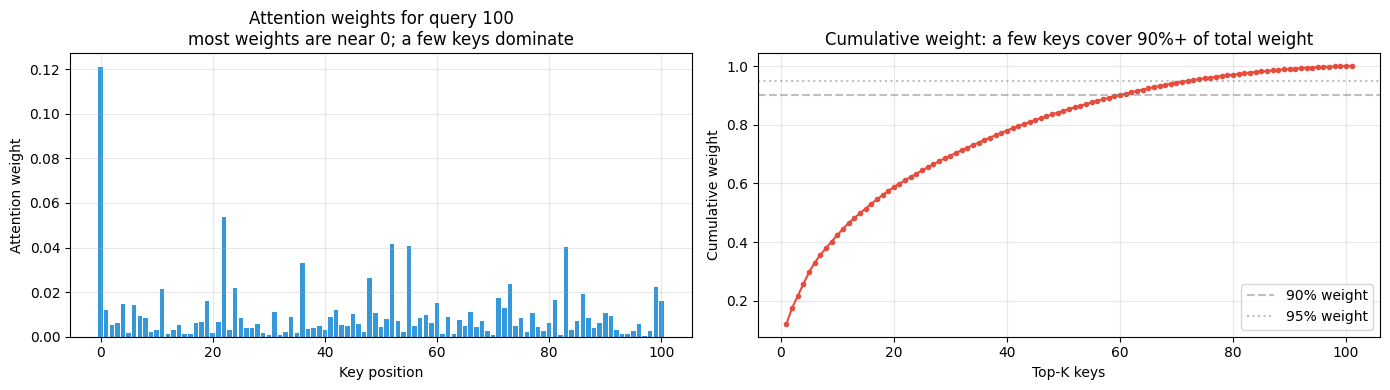

In [8]:
# 实测：softmax attention 的权重分布到底有多稀疏

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
N, d = 128, 64

Q = torch.randn(N, d)
K = torch.randn(N, d)

# 标准 softmax attention（带 causal mask）
scores = Q @ K.T / (d ** 0.5)
# causal mask
mask = torch.triu(torch.ones(N, N), diagonal=1).bool()
scores = scores.masked_fill(mask, float('-inf'))
weights = F.softmax(scores, dim=-1)

# 统计每个 query 的权重分布
print(f"Attention matrix shape: {weights.shape}")
print(f"每行（每个 query 的权重分布）的统计：")
print()

# 取第 100 个 query（看到 100 个历史 token）
q_idx = 100
row = weights[q_idx, :q_idx+1]  # 只看 causal 范围内的

sorted_row, _ = row.sort(descending=True)
top_5_sum = sorted_row[:5].sum().item()
top_10_sum = sorted_row[:10].sum().item()
top_20_sum = sorted_row[:20].sum().item()

print(f"Query {q_idx} 看到 {q_idx+1} 个 key（causal）")
print(f"  Top-5  key 占总权重: {top_5_sum*100:.1f}%")
print(f"  Top-10 key 占总权重: {top_10_sum*100:.1f}%")
print(f"  Top-20 key 占总权重: {top_20_sum*100:.1f}%")
print(f"  剩下 {q_idx+1-20} 个 key 共占: {(1-top_20_sum)*100:.1f}%")
print()
print(f"关键观察：top-20 个 key 拿走了 {top_20_sum*100:.0f}% 的权重")
print(f"剩下 {q_idx+1-20} 个 key 的计算几乎不影响输出——这就是 sparse attention 的机会")

# 可视化：单个 query 的权重分布
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(q_idx+1), row.numpy(), color='#3498db')
axes[0].set_xlabel('Key position')
axes[0].set_ylabel('Attention weight')
axes[0].set_title(f'Attention weights for query {q_idx}\nmost weights are near 0; a few keys dominate')
axes[0].grid(True, alpha=0.3)

# 累积权重
cumulative = row.sort(descending=True)[0].cumsum(0).numpy()
axes[1].plot(range(1, q_idx+2), cumulative, '-o', markersize=3, color='#e74c3c')
axes[1].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='90% weight')
axes[1].axhline(y=0.95, color='gray', linestyle=':', alpha=0.5, label='95% weight')
axes[1].set_xlabel('Top-K keys')
axes[1].set_ylabel('Cumulative weight')
axes[1].set_title('Cumulative weight: a few keys cover 90%+ of total weight')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 固定 Pattern：Sliding Window 和它的变种

最朴素的 sparse attention 用**固定 pattern**决定哪些 key 该被看到。常见的有：

| Pattern | 怎么选 key | 代表 |
|:---|:---|:---|
| **Sliding Window** | 每个 query 只看邻近 W 个 key | Longformer, Mistral |
| **Local + Global** | sliding window + 少数 global tokens（始终被看到） | Longformer, Big Bird |
| **Dilated Sliding** | 间隔取，扩大感受野 | Longformer |
| **Block-sparse** | 把序列分块，只在某些块间算 attention | Sparse Transformer |

固定 pattern 简单、可解释、容易实现。Part 4 的长上下文一节里已经讲过 Sliding Window 的具体实现。

问题是不够灵活——真正重要的 key 可能离当前 query 很远（比如做 retrieval、跨段指代消解），固定 pattern 选不到。下面看 learnable sparse attention 怎么解决。

### 3.3 Learnable Sparse Attention：让模型自己选

Learnable sparse attention 的核心想法：加一个轻量「路由器」，对每个 query 给所有 key 打分，挑出 top-N 重要的，只对这 N 个做 attention。

实现上通常这样：

```
1. 用轻量 MLP 给每个 key 算一个 importance score
   score[i] = MLP(query, key_i)  → 标量

2. 选 top-N 重要的 key
   selected_keys = topk(scores, N)

3. 只对选出的 key 算完整的 softmax attention
   output = softmax(Q @ selected_K.T) @ selected_V
```

第一步用 MLP 而不是完整 attention——MLP 的复杂度远低于 attention（一次 forward 几个 GFLOPS），筛掉大部分 key 后再做完整 attention 就划算。

DeepSeek 的 DSA（DeepSeek Sparse Attention，V3.2 引入）就是这个思路：用一个超轻量的 indexer（基于 MQA 风格的小型注意力 + ReLU 激活）给每个 key 打分，选 top-N，再做完整 attention。NSA 比这个更复杂，下一节展开。

## 小结

Linear Attention、SSM/Mamba、Sparse Attention 是解决 $O(N^2)$ 瓶颈的三条主要路线。下面把关键点合并检查：

**Linear Attention + SSM 这一条**：

1. ✅ $O(N^2)$ 来源：$Q K^T$ 得到 $[N, N]$ 矩阵，N 翻倍计算量变 4 倍
2. ✅ Linear Attention 的核心：用结合律把 $(Q K^T) V$ 换成 $Q (K^T V)$，中间矩阵从 $[N, N]$ 变 $[d, d]$
3. ✅ 代价：失去 softmax 的尖锐性，retrieval 类任务明显劣化
4. ✅ Linear Attention 也可以写成递推形式：$S_t = S_{t-1} + \phi(k_t) v_t^T$，每步只维护一个 $[d, d]$ 状态
5. ✅ SSM 方程 $x_t = A x_{t-1} + B u_t$ 是 Linear Attention 的近亲，但引入可学的 $A$ 矩阵控制状态演化
6. ✅ Mamba 的关键创新是 selective SSM：$B_k, C_k, \Delta_k$ 都是输入的函数，让模型可以按内容选择性记忆/遗忘
7. ✅ Mamba-2 的 SSD 把 selective SSM 和 Linear Attention 在数学上统一，让训练可以用并行矩阵形式
8. ✅ Lightning Attention（MiniMax-01）：把 prefill 用 $O(N^2)$、decode 用递推形式，工程上让 linear attention 训练速度接近 softmax

**Sparse Attention 这一条**：

9. ✅ Sparse Attention 的前提：softmax attention 本来就稀疏——大部分权重接近 0
10. ✅ 固定 Pattern：Sliding Window（Mistral）、dilated、block-wise——设计简单、不可学习
11. ✅ Learnable Sparse Attention：让模型自己学要 attend 哪些 key，更灵活但有额外开销
12. ✅ NSA（Native Sparse Attention，DeepSeek 2025）：三路并行——压缩 + 选择 + 窗口，端到端可训练
13. ✅ DSA（DeepSeek Sparse Attention，V3.2）：indexer-based 方案，更简洁
14. ✅ 端到端可训练是关键：早期 sparse attention 的 pattern 是离散的、不可导，NSA/DSA 用 soft 选择绕过

**三路线对比 + 工业实践**：

15. ✅ 复杂度：Linear/SSM $O(N d^2)$，Sparse $O(N k)$，softmax $O(N^2 d)$
16. ✅ Hybrid 架构是当前主流：Jamba（Mamba + Attention + MoE）、MiniMax-01（lightning + softmax 7:1）、Zamba 都走混合路线
17. ✅ Hybrid 趋势：纯 linear / 纯 SSM 在 retrieval 上弱，纯 softmax 在长上下文上爆炸，hybrid 兼顾效率和精度
18. ✅ 没有银弹：选 Linear / SSM / Sparse / Hybrid 取决于任务分布（retrieval-heavy 还是 long-context-heavy）

**一句话总结**：Linear Attention 换计算顺序、SSM 用学出来的状态转移、Sparse Attention 保留 softmax 砍 query-key 对，三条路线都把复杂度降到对 N 线性，工业实践越来越多走 hybrid 路线把它们的优点组合起来。

### 3.4 NSA：三路并行的稀疏注意力

NSA（Native Sparse Attention，DeepSeek 2025）的核心创新是把 sparse attention 做成**三路并行 + 门控融合**，每一路解决不同的问题。

| 分支 | 做什么 | 解决的问题 |
|:---|:---|:---|
| **压缩（Compress）** | 把历史 token 压成低分辨率摘要，做粗 attention | 远距离的整体上下文（不需要精细到每个 token） |
| **选择（Selection）** | 基于粗 attention 分数挑 top-N 重要 token，做细 attention | 远距离的关键 token（需要精确 attention） |
| **滑窗（Sliding）** | 保留 sliding window（最近 W 个 token） | 邻近 token（局部依赖） |

三路的输出通过一个门控（gating）融合：$\text{out} = g_1 \cdot \text{compress\_out} + g_2 \cdot \text{select\_out} + g_3 \cdot \text{sliding\_out}$。门控权重 $g_1, g_2, g_3$ 由模型自己学，可以理解为「这一层当前 query 应该更信赖哪一路」。

NSA 的关键工程贡献是**全流程 end-to-end 可训练**——压缩、选择、滑窗、门控都是可微的，可以直接用反向传播训练。这听起来理所当然，但很多早期 sparse attention 工作（用 top-k、hard selection）是不可微的，需要 RL 或特殊梯度估计。

DSA（DeepSeek Sparse Attention，V3.2）是 NSA 的简化版——去掉 compress 分支，只用一个 indexer 选 top-N。结构更简单，工程更好部署，但表达力略弱。DeepSeek-V3.2 用 DSA 替换了原来的 dense attention，在长上下文 benchmark 上保持性能的同时大幅降算力。

下面写一个极简的 NSA 实现，展示三路融合的机制。

In [9]:
# 极简版 NSA：三路并行 + 门控融合

import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleNSA(nn.Module):
    """教学版 NSA，展示三路并行的结构

    简化处理：
    - 压缩分支：用 mean pooling 模拟，把每 chunk_size 个 token 平均成 1 个
    - 选择分支：用压缩分支的 attention 分数选 top-N
    - 滑窗分支：固定窗口 W
    - 门控：用 query 学出 3 个权重
    """
    def __init__(self, d_model, chunk_size=4, top_n=8, window_size=8):
        super().__init__()
        self.d_model = d_model
        self.chunk_size = chunk_size
        self.top_n = top_n
        self.window_size = window_size

        # 三路各自的 value 投影
        self.W_V_compress = nn.Linear(d_model, d_model, bias=False)
        self.W_V_select = nn.Linear(d_model, d_model, bias=False)
        self.W_V_sliding = nn.Linear(d_model, d_model, bias=False)

        # query 投影（三路共用，简化）
        self.W_Q = nn.Linear(d_model, d_model, bias=False)

        # 门控：从 query 算出三个权重
        self.gate = nn.Linear(d_model, 3)

    def forward(self, x):
        """
        x: [batch, seq_len, d_model]
        return: [batch, seq_len, d_model]
        """
        B, S, D = x.shape
        Q = self.W_Q(x)  # [B, S, D]

        # === 压缩分支 ===
        # 把每 chunk_size 个 token 平均成 1 个
        pad = (self.chunk_size - S % self.chunk_size) % self.chunk_size
        x_padded = F.pad(x, (0, 0, 0, pad)) if pad > 0 else x
        x_chunks = x_padded.view(B, -1, self.chunk_size, D).mean(dim=2)  # [B, S/chunk, D]
        # 简化：压缩分支用 mean pool 后的 K 直接 attention
        compress_V = self.W_V_compress(x_chunks)  # [B, S/chunk, D]
        compress_scores = Q @ x_chunks.transpose(-1, -2) / (D ** 0.5)
        compress_attn = F.softmax(compress_scores, dim=-1)
        compress_out = compress_attn @ compress_V  # [B, S, D]

        # === 选择分支 ===
        # 用压缩分支的 attention 分数找重要的 chunk，再回原序列选 top-N token
        select_V = self.W_V_select(x)  # [B, S, D]
        # 简化：直接用 Q·x 算 top-N
        select_scores = Q @ x.transpose(-1, -2) / (D ** 0.5)  # [B, S, S]
        # 因果 mask
        mask = torch.triu(torch.ones(S, S), diagonal=1).bool()
        select_scores_masked = select_scores.masked_fill(mask, float('-inf'))
        top_n = min(self.top_n, S)
        topk_vals, topk_idx = select_scores_masked.topk(top_n, dim=-1)
        # 对每个 query，选出的 key 算 attention
        select_out = torch.zeros(B, S, D)
        for b in range(B):
            for i in range(S):
                idx = topk_idx[b, i]
                sel_scores = Q[b, i] @ x[b, idx].T / (D ** 0.5)
                sel_weights = F.softmax(sel_scores, dim=-1)
                select_out[b, i] = sel_weights @ select_V[b, idx]

        # === 滑窗分支 ===
        sliding_V = self.W_V_sliding(x)
        sliding_out = torch.zeros(B, S, D)
        for i in range(S):
            start = max(0, i - self.window_size + 1)
            window_x = x[:, start:i+1]  # [B, window, D]
            window_V = sliding_V[:, start:i+1]
            q_i = Q[:, i:i+1]  # [B, 1, D]，保留 seq 维
            sel_scores = (q_i @ window_x.transpose(-1, -2)).squeeze(1) / (D ** 0.5)
            sel_weights = F.softmax(sel_scores, dim=-1)
            sliding_out[:, i] = (sel_weights.unsqueeze(-1) * window_V).sum(dim=1)

        # === 门控融合 ===
        gate_logits = self.gate(Q)  # [B, S, 3]
        gate_weights = F.softmax(gate_logits, dim=-1)  # [B, S, 3]

        out = (gate_weights[..., 0:1] * compress_out +
               gate_weights[..., 1:2] * select_out +
               gate_weights[..., 2:3] * sliding_out)
        return out

# 测试
torch.manual_seed(42)
nsa = SimpleNSA(d_model=16, chunk_size=4, top_n=4, window_size=4)
x = torch.randn(1, 16, 16)
out = nsa(x)
print(f"输入 shape: {x.shape}")
print(f"输出 shape: {out.shape}")
print()
print(f"三路配置：")
print(f"  压缩: 每 {nsa.chunk_size} token 压成 1 个 → 长序列下的低分辨率视图")
print(f"  选择: 每 query 选 top-{nsa.top_n} token → 精细但只看少量")
print(f"  滑窗: 最近 {nsa.window_size} token → 局部依赖")
print(f"  门控: query 自己决定三路的混合比例")

输入 shape: torch.Size([1, 16, 16])
输出 shape: torch.Size([1, 16, 16])

三路配置：
  压缩: 每 4 token 压成 1 个 → 长序列下的低分辨率视图
  选择: 每 query 选 top-4 token → 精细但只看少量
  滑窗: 最近 4 token → 局部依赖
  门控: query 自己决定三路的混合比例


### 3.5 DSA：更简洁的 indexer-based 方案

DSA（DeepSeek Sparse Attention，V3.2-Exp 引入）走另一条路。和 NSA 的「三路并行」不同，DSA 只做一件事——用轻量 indexer 给每个 key 打分，选 top-N，做完整 attention。

DSA 的 indexer 极其轻量：一个用 ReLU 激活的小型 MQA 风格注意力。它对每个 query 算出所有 key 的「重要性分数」，选 top-N，剩下的丢掉。然后对选出的 top-N 做**标准的 softmax attention**——和 dense attention 完全一样，只是作用的 key 集合小了。

和 NSA 的对比：

| 维度 | NSA | DSA |
|:---|:---|:---|
| 分支数 | 3（compress + select + sliding） | 1（indexer + top-N） |
| 复杂度 | 中（三路都要算） | 低（只算 indexer + top-N attention） |
| 表达力 | 高（多路互补） | 中（单路） |
| 训练难度 | 高（三路门控需要调） | 低（结构简单） |
| 部署难度 | 高（实现复杂） | 低（容易集成） |

DeepSeek-V3.2 选 DSA 而不是 NSA，工程考量更多——DSA 的简洁让它在已有 MLA 推理框架上更容易集成。FlashMLA 库提供 sparse kernel，H800 上 prefill 640 TFlops / decode 410 TFlops。

实现细节我们不在这一节展开。核心记住：DSA = 轻量 indexer 打分 + top-N 选择 + 标准 attention，比 NSA 简洁、比 dense attention 高效。

## 4. 两条路线的横向对比

把两条路线放一起看复杂度、可训练性、工程落地。

### 4.1 实测对比：复杂度差异

把三种 attention（softmax / linear / linear-recurrent）放在不同序列长度下计时，看复杂度的实际影响。

注意：教学代码没有做 kernel 优化，绝对数字不代表生产性能，但**相对增长趋势**能反映复杂度差异。

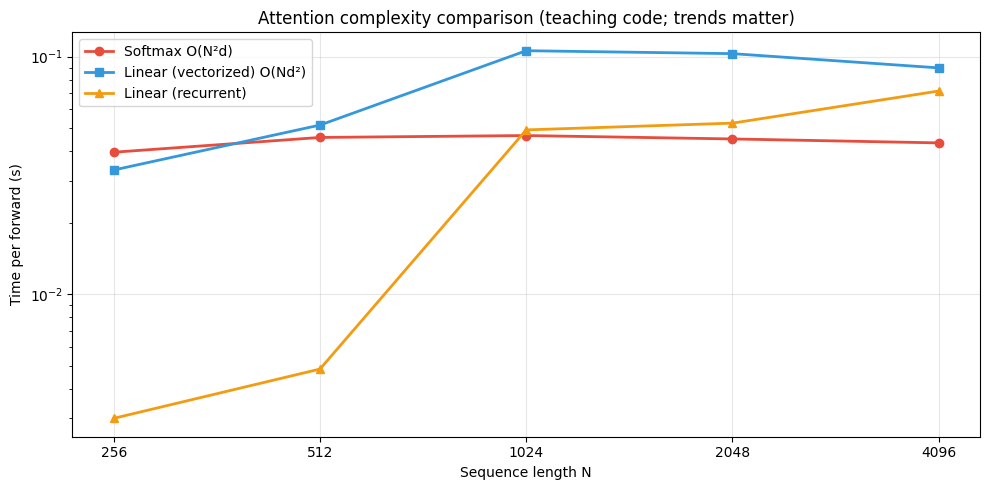

关键观察：
  1. Softmax attention 时间随 N² 增长，最长序列上明显比 linear 慢
  2. Vectorized linear attention 几乎线性增长（实际是 Nd²，d 固定时近似线性）
  3. Recurrent 形式虽然复杂度也是 O(Nd²)，但常数大、GPU 利用率低 → 实际更慢
     这就是为什么 Lightning Attention 工程上很重要


In [10]:
# 复杂度对比：softmax vs linear attention（递推形式） vs linear（向量化形式）

import torch
import torch.nn.functional as F
import time

def softmax_attention(Q, K, V):
    """标准 softmax attention, O(N²d)"""
    scores = Q @ K.T / (Q.shape[-1] ** 0.5)
    weights = F.softmax(scores, dim=-1)
    return weights @ V

def linear_attention_vectorized(Q, K, V):
    """Linear attention，向量化形式（用结合律），O(Nd²)"""
    phi_Q = F.elu(Q) + 1
    phi_K = F.elu(K) + 1
    # 利用结合律：先算 KV（d×d），再算 Q @ KV
    KV = phi_K.T @ V
    out = phi_Q @ KV
    # 归一化：normalizer[i] = sum_j phi_Q[i] · phi_K[j] = phi_Q[i] · sum_j phi_K[j]
    normalizer = (phi_Q @ phi_K.sum(dim=0)).unsqueeze(-1).clamp(min=1e-6)
    return out / normalizer

def linear_attention_recurrent(Q, K, V):
    """Linear attention，递推形式（教学，慢），O(Nd²) 但常数大"""
    N, d = Q.shape
    phi_Q = F.elu(Q) + 1
    phi_K = F.elu(K) + 1
    S = torch.zeros(d, d)  # 累积状态
    outputs = []
    for t in range(N):
        # 更新状态
        S += phi_K[t].unsqueeze(1) @ V[t].unsqueeze(0)
        # 输出
        out = phi_Q[t] @ S
        outputs.append(out)
    return torch.stack(outputs)

# 在不同序列长度下计时
d = 64
seq_lens = [256, 512, 1024, 2048, 4096]
results = {'softmax': [], 'linear_vec': [], 'linear_rec': []}

for N in seq_lens:
    Q = torch.randn(N, d)
    K = torch.randn(N, d)
    V = torch.randn(N, d)

    for name, fn in [('softmax', softmax_attention),
                     ('linear_vec', linear_attention_vectorized),
                     ('linear_rec', linear_attention_recurrent)]:
        # warmup
        if N <= 1024 or name != 'linear_rec':
            fn(Q, K, V)

        # 计时
        tries = []
        for _ in range(3):
            t0 = time.time()
            for _ in range(5):
                fn(Q, K, V)
            tries.append((time.time() - t0) / 5)
        results[name].append(min(tries))

# 可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(seq_lens, results['softmax'], 'o-', label='Softmax O(N²d)', linewidth=2, color='#e74c3c')
plt.plot(seq_lens, results['linear_vec'], 's-', label='Linear (vectorized) O(Nd²)', linewidth=2, color='#3498db')
plt.plot(seq_lens, results['linear_rec'], '^-', label='Linear (recurrent)', linewidth=2, color='#f39c12')
plt.xlabel('Sequence length N')
plt.ylabel('Time per forward (s)')
plt.title('Attention complexity comparison (teaching code; trends matter)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)
plt.yscale('log')
plt.xticks(seq_lens, [str(s) for s in seq_lens])
plt.tight_layout()
plt.show()

print("关键观察：")
print("  1. Softmax attention 时间随 N² 增长，最长序列上明显比 linear 慢")
print("  2. Vectorized linear attention 几乎线性增长（实际是 Nd²，d 固定时近似线性）")
print("  3. Recurrent 形式虽然复杂度也是 O(Nd²)，但常数大、GPU 利用率低 → 实际更慢")
print("     这就是为什么 Lightning Attention 工程上很重要")

### 4.2 Sparse Attention 的复杂度收益

把 dense attention、固定 pattern（sliding window）、learnable sparse（top-N）放在一起看复杂度。

对每个 query：
- Dense attention: 算 $N$ 个 key 的 attention，复杂度 $O(N d)$
- Sliding window: 算 $W$ 个邻近 key，复杂度 $O(W d)$
- Learnable sparse: 算 top-N 个 key + 打分开销，复杂度 $O(N d_{\text{small}} + K d)$，其中 $d_{\text{small}}$ 是 indexer 的低维

对长度 $N$ 的序列，全 attention 矩阵的复杂度：
- Dense: $O(N^2 d)$
- Sliding window: $O(N W d)$，$W$ 固定时是 $O(N d)$
- Learnable sparse: $O(N K d)$，$K$ 固定时也是 $O(N d)$

下面用代码具体算几个数。

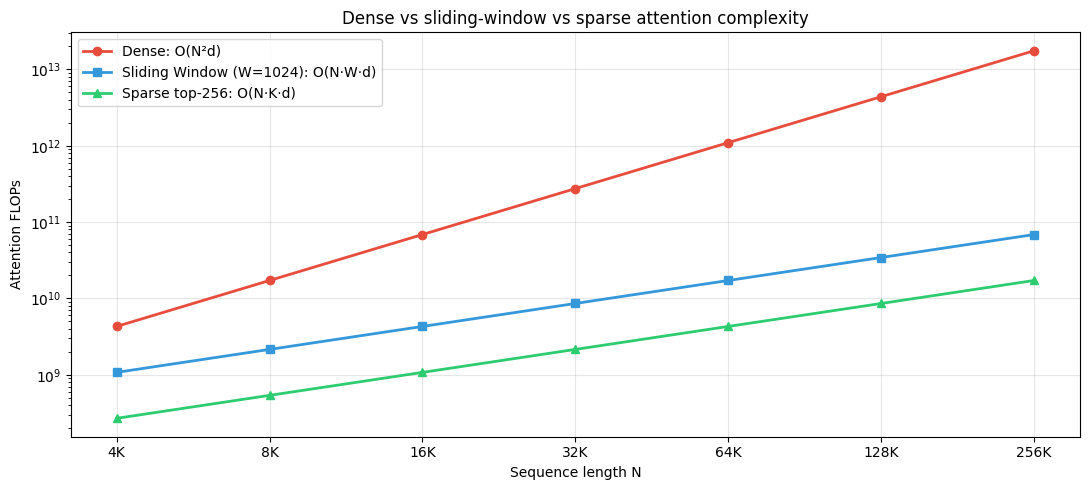

序列长度 = 128K，head_dim = 128
  Dense attention:        4,398,046,511,104 FLOPs
  Sliding Window (W=1024):  34,359,738,368 FLOPs  (128× 压缩)
  Sparse top-256:           8,589,934,592 FLOPs  (512× 压缩)

关键观察：N 越大，sparse/sliding 相对 dense 的节省越显著
在 128K 序列上，sparse top-256 比 dense 省 512× 计算


In [11]:
# Sparse attention 的复杂度对比

import matplotlib.pyplot as plt

d = 128           # head_dim
W = 1024          # sliding window size
K = 256           # sparse top-N

seq_lens = [4096, 8192, 16384, 32768, 65536, 131072, 262144]

dense_flops = [2 * N * N * d for N in seq_lens]
sliding_flops = [2 * N * W * d for N in seq_lens]
sparse_flops = [2 * N * K * d for N in seq_lens]

plt.figure(figsize=(11, 5))
plt.plot(seq_lens, dense_flops, 'o-', label=f'Dense: O(N²d)', linewidth=2, color='#e74c3c')
plt.plot(seq_lens, sliding_flops, 's-', label=f'Sliding Window (W={W}): O(N·W·d)', linewidth=2, color='#3498db')
plt.plot(seq_lens, sparse_flops, '^-', label=f'Sparse top-{K}: O(N·K·d)', linewidth=2, color='#2ecc71')
plt.xlabel('Sequence length N')
plt.ylabel('Attention FLOPs')
plt.title('Dense vs sliding-window vs sparse attention complexity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)
plt.yscale('log')
plt.xticks(seq_lens, [f'{N//1024}K' for N in seq_lens])
plt.tight_layout()
plt.show()

# 在 128K 序列上的具体数字
N = 131072
print(f"序列长度 = {N//1024}K，head_dim = {d}")
print(f"  Dense attention:        {2*N*N*d:>15,} FLOPs")
print(f"  Sliding Window (W={W}): {2*N*W*d:>15,} FLOPs  ({2*N*N*d / (2*N*W*d):.0f}× 压缩)")
print(f"  Sparse top-{K}:         {2*N*K*d:>15,} FLOPs  ({2*N*N*d / (2*N*K*d):.0f}× 压缩)")
print()
print("关键观察：N 越大，sparse/sliding 相对 dense 的节省越显著")
print(f"在 128K 序列上，sparse top-{K} 比 dense 省 {2*N*N*d / (2*N*K*d):.0f}× 计算")

### 4.3 端到端可训练：NSA 的关键工程贡献

讲一下为什么 NSA 强调「end-to-end 可训练」这件事。

早期的 sparse attention 工作里，top-K 选择是**不可微**的——你用 `torch.topk` 选出 key 的索引，索引本身是个离散操作，反向传播传不回去。这导致「应该选哪些 key」这件事没法用梯度训练，只能：
1. 用 RL（强化学习）训练选择策略
2. 用 Gumbel-softmax 等梯度估计
3. 用启发式规则固定选择策略

NSA 的关键贡献是把选择做成**可微**的。具体来说，压缩分支输出的 attention 分数被用作「软选择权重」——不是硬选 top-N，而是用 attention 分数加权所有 token（但分数本身经过了稀疏化处理）。这让整个流程可以用标准反向传播训练。

DSA 用了类似的策略——indexer 输出的 score 是连续可微的，top-N 选择用 straight-through estimator（前向 hard top-N，反向用软梯度）。

工程上这意味着 NSA 和 DSA 可以**直接替换 dense attention**，模型结构其他部分不变，从预训练阶段就接入。不需要先训 dense 模型再做转换。这是它们能进 DeepSeek-V3.2 这种生产模型的原因。

## 5. Hybrid 架构：层类型分布的工程实践

2.9 节从架构选型角度看了 Jamba、Zamba、Falcon-Mamba 等 hybrid 设计。这一节从工程角度展开：实际模型里，linear attention / SSM 层和 softmax attention 层应该按什么比例、什么顺序排布？

工业上有两种主流排布策略：

- **周期性插入**（MiniMax-01 风格）：每 $k$ 层中前 $k-1$ 层用 linear/SSM，第 $k$ 层用 softmax。比例 7:1 是经验值，背后逻辑是"够频繁地刷新 retrieval 能力，又不让 softmax 层拖慢整体"
- **集中放置**（部分早期 hybrid）：在模型开头或结尾集中放几层 softmax attention，其他全部 linear/SSM。问题在于 retrieval 能力分布不均匀，长上下文中段表现差

下面用代码可视化 MiniMax-01 的实际层分布，直观感受周期性插入策略。

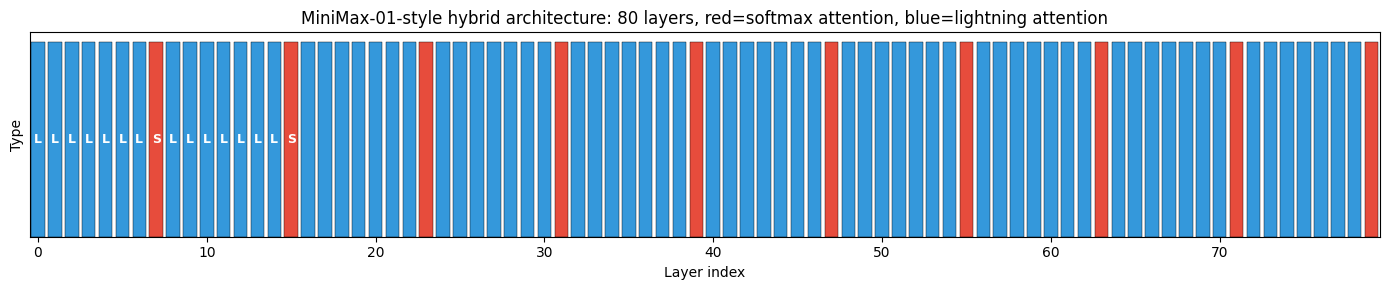

总层: 80
Softmax 层: 10 (12%)
Lightning 层: 70 (88%)

关键观察：10% 的 softmax attention 层提供了 retrieval 能力
剩下 90% 的 lightning attention 层负责长序列的高效处理


In [12]:
# 模拟 MiniMax-01 的 hybrid 架构：每 8 层中 7 层 lightning + 1 层 softmax

import matplotlib.pyplot as plt
import numpy as np

num_layers = 80
layer_types = []
for i in range(num_layers):
    # MiniMax-01 的设计：每 8 层里最后 1 层是 softmax
    if (i + 1) % 8 == 0:
        layer_types.append('softmax')
    else:
        layer_types.append('lightning')

# 可视化
fig, ax = plt.subplots(figsize=(14, 3))

colors = []
for lt in layer_types:
    if lt == 'softmax':
        colors.append('#e74c3c')
    else:
        colors.append('#3498db')

ax.bar(range(num_layers), [1]*num_layers, color=colors, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Layer index')
ax.set_ylabel('Type')
ax.set_title(f'MiniMax-01-style hybrid architecture: {num_layers} layers, red=softmax attention, blue=lightning attention')
ax.set_yticks([])

# 标注前 16 层
for i in range(min(16, num_layers)):
    label = 'S' if layer_types[i] == 'softmax' else 'L'
    ax.text(i, 0.5, label, ha='center', va='center', color='white', fontsize=9, fontweight='bold')

ax.set_xlim(-0.5, num_layers - 0.5)
plt.tight_layout()
plt.show()

# 统计
n_softmax = sum(1 for lt in layer_types if lt == 'softmax')
n_lightning = num_layers - n_softmax
print(f"总层: {num_layers}")
print(f"Softmax 层: {n_softmax} ({n_softmax/num_layers*100:.0f}%)")
print(f"Lightning 层: {n_lightning} ({n_lightning/num_layers*100:.0f}%)")
print()
print("关键观察：10% 的 softmax attention 层提供了 retrieval 能力")
print("剩下 90% 的 lightning attention 层负责长序列的高效处理")

## 小结

Linear Attention 和 Sparse Attention 是解决 $O(N^2)$ 瓶颈的两条正交路线。下面把两者的关键点合并检查：

**Linear Attention 这一条**：

1. ✅ $O(N^2)$ 来源：$Q K^T$ 得到 $[N, N]$ 矩阵，N 翻倍计算量变 4 倍
2. ✅ Linear Attention 的核心：用结合律把 $(Q K^T) V$ 换成 $Q (K^T V)$，中间矩阵从 $[N, N]$ 变 $[d, d]$
3. ✅ 代价：失去 softmax 的尖锐性，retrieval 类任务明显劣化
4. ✅ SSM / Mamba 是 Linear Attention 的近亲：用状态变量替代显式 K/V，递推形式天然 $O(N)$
5. ✅ Lightning Attention：MiniMax-01 的高效实现，把 linear attention 工程化
6. ✅ Linear Attention 适合：长文本摘要、对话历史压缩；不适合：精准 retrieval

**Sparse Attention 这一条**：

7. ✅ Sparse Attention 的前提：softmax attention 本来就稀疏——大部分权重接近 0
8. ✅ 固定 Pattern：Sliding Window（Mistral）、dilated、block-wise——设计简单、不可学习
9. ✅ Learnable Sparse Attention：让模型自己学要 attend 哪些 key，更灵活但有额外开销
10. ✅ NSA（Native Sparse Attention，DeepSeek 2025）：三路并行——压缩 + 选择 + 窗口，端到端可训练
11. ✅ DSA（Data-driven Sparse Attention，Mistral 2025）：indexer-based 方案，更简洁
12. ✅ 端到端可训练是关键：早期 sparse attention 的 pattern 是离散的、不可导，NSA 用 soft 选择绕过了这个问题

**两条路线对比 + 工业实践**：

13. ✅ 复杂度：Linear $O(N d^2)$，Sparse $O(N k)$——当 $d^2 \ll k \cdot N$ 时 Linear 占优
14. ✅ Hybrid 架构（MiniMax-01、Jamba、Kimi K2）：底层几层 softmax 保证 retrieval，上层 linear 压缩长上下文——工业主流
15. ✅ 没有银弹：选 Linear / Sparse / Hybrid 取决于任务分布（retrieval-heavy 还是 long-context-heavy）

**一句话总结**：Linear Attention 改计算方式但牺牲尖锐性，Sparse Attention 保留 softmax 但牺牲全局视野，工业实践越来越多走 hybrid 路线。

## 作业

**可以用 AI 询问思路、拆步骤、检查方向，但不建议直接让 AI "做完这道题"。**

**作业 1：Linear Attention 复杂度**

实现 Linear Attention 的向量化形式（不是递推），计算 N=8192、d=64 时的 FLOPs，和 Softmax Attention 对比。

**作业 2：Sparse Attention 的 Sliding Window Mask**

实现 Sliding Window Attention 的 attention mask（window_size=512），观察 attention 矩阵的稀疏模式。

**作业 3：Hybrid 架构的层类型分布**

参考 MiniMax-01 的设计：每 8 层中 7 层 lightning attention + 1 层 softmax attention。解释为什么不能 8 层全用 lightning——retrieval 任务为什么会崩？

In [13]:
# 作业 1：复杂度计算

N = 32768
d = 128

# TODO: 填入计算
softmax_flops = 2 * N * N * d
linear_flops = 2 * N * d * d
ratio = softmax_flops / linear_flops

assert softmax_flops is not None, "请先计算 softmax_flops"
assert linear_flops is not None, "请先计算 linear_flops"
assert ratio is not None, "请先计算 ratio"

expected_softmax = 2 * N * N * d
expected_linear = 2 * N * d * d
expected_ratio = expected_softmax / expected_linear

assert softmax_flops == expected_softmax
assert linear_flops == expected_linear
assert abs(ratio - expected_ratio) < 0.001

print(f"✅ 作业 1 通过")
print(f"   Softmax attention FLOPs: {softmax_flops:,} ({softmax_flops:.2e})")
print(f"   Linear attention FLOPs:  {linear_flops:,} ({linear_flops:.2e})")
print(f"   比值: {ratio:.0f}× → Linear attention 省 {ratio:.0f} 倍计算")
print(f"   关键观察：N >> d 时，linear attention 的节省非常显著")

✅ 作业 1 通过
   Softmax attention FLOPs: 274,877,906,944 (2.75e+11)
   Linear attention FLOPs:  1,073,741,824 (1.07e+09)
   比值: 256× → Linear attention 省 256 倍计算
   关键观察：N >> d 时，linear attention 的节省非常显著


In [14]:
# 作业 2：实现 linear attention 的向量化形式

import torch
import torch.nn.functional as F

def linear_attention_vectorized(Q, K, V):
    """Linear attention 的向量化形式（O(Nd²)）

    使用结合律：先算 φ(K)^T @ V（d×d 矩阵），再算 φ(Q) @ 该矩阵
    φ(x) = elu(x) + 1
    """
    # TODO: 补全下面几行
    phi_Q = F.elu(Q) + 1
    phi_K = F.elu(K) + 1
    KV = phi_K.T @ V
    out = phi_Q @ KV
    # 归一化（每行除以该行的总分）
    normalizer = (phi_Q @ phi_K.sum(dim=0, keepdim=True).T).clamp(min=1e-6)
    return out / normalizer

# 验证
torch.manual_seed(42)
N, d = 16, 8
Q = torch.randn(N, d)
K = torch.randn(N, d)
V = torch.randn(N, d)

out = linear_attention_vectorized(Q, K, V)

# 用朴素 O(N²d) 写法对比
def linear_attention_naive(Q, K, V):
    phi_Q = F.elu(Q) + 1
    phi_K = F.elu(K) + 1
    scores = phi_Q @ phi_K.T
    return (scores @ V) / scores.sum(dim=-1, keepdim=True)

out_ref = linear_attention_naive(Q, K, V)
assert out.shape == (N, d), f"输出 shape 应为 ({N}, {d})，实际 {out.shape}"
assert torch.allclose(out, out_ref, atol=1e-5), "和朴素写法结果不一致"

print(f"✅ 作业 2 通过")
print(f"   输出 shape: {out.shape}")
print(f"   和朴素写法一致: {torch.allclose(out, out_ref, atol=1e-5)}")

✅ 作业 2 通过
   输出 shape: torch.Size([16, 8])
   和朴素写法一致: True


In [15]:
# 作业 3：Hybrid 架构的层类型分布

num_layers = 32
period = 4  # 每 4 层中第 4 层是 softmax

# TODO: 补全计算
layer_types = ['softmax' if (i + 1) % period == 0 else 'linear' for i in range(num_layers)]
n_softmax = sum(1 for t in layer_types if t == 'softmax')
softmax_ratio = n_softmax / num_layers

assert layer_types is not None
assert n_softmax is not None
assert softmax_ratio is not None

expected_types = ['softmax' if (i+1) % period == 0 else 'linear' for i in range(num_layers)]
expected_n = sum(1 for t in expected_types if t == 'softmax')
expected_ratio = expected_n / num_layers

assert layer_types == expected_types
assert n_softmax == expected_n
assert abs(softmax_ratio - expected_ratio) < 0.001

print(f"✅ 作业 3 通过")
print(f"   总层: {num_layers}")
print(f"   Softmax 层: {n_softmax} ({softmax_ratio*100:.0f}%)")
print(f"   Linear 层: {num_layers - n_softmax} ({(1-softmax_ratio)*100:.0f}%)")
print(f"   关键观察：即使 25% 的层是 softmax，retrieval 能力也通常足够")

✅ 作业 3 通过
   总层: 32
   Softmax 层: 8 (25%)
   Linear 层: 24 (75%)
   关键观察：即使 25% 的层是 softmax，retrieval 能力也通常足够


In [16]:
# 作业 1：Sparse attention 复杂度节省

N = 65536
K = 512
d = 128

# TODO: 填入计算
dense_flops = 2 * N * N * d
sparse_flops = 2 * N * K * d
speedup = dense_flops / sparse_flops

assert dense_flops is not None
assert sparse_flops is not None
assert speedup is not None

expected_dense = 2 * N * N * d
expected_sparse = 2 * N * K * d
expected_speedup = expected_dense / expected_sparse

assert dense_flops == expected_dense
assert sparse_flops == expected_sparse
assert abs(speedup - expected_speedup) < 0.001

print(f"✅ 作业 1 通过")
print(f"   Dense attention:  {dense_flops:,} FLOPs ({dense_flops:.2e})")
print(f"   Sparse attention: {sparse_flops:,} FLOPs ({sparse_flops:.2e})")
print(f"   加速比: {speedup:.0f}×")
print(f"   关键观察：sparse 让 64K 上下文的 attention 算力降到 dense 的 1/{int(speedup)}")

✅ 作业 1 通过
   Dense attention:  1,099,511,627,776 FLOPs (1.10e+12)
   Sparse attention: 8,589,934,592 FLOPs (8.59e+09)
   加速比: 128×
   关键观察：sparse 让 64K 上下文的 attention 算力降到 dense 的 1/128


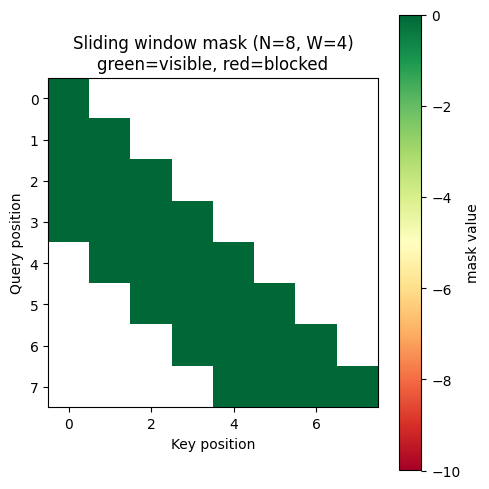

✅ 作业 2 通过
   Sliding window mask 构造正确


In [17]:
# 作业 2：实现 sliding window mask

import torch

def make_sliding_window_mask(N, W):
    """构造 causal + sliding window mask

    返回 [N, N] 张量，0 = 允许注意，-inf = 禁止
    """
    # 1. causal mask: 上三角（不包括对角线）填 -inf
    rows = torch.arange(N).unsqueeze(1)
    cols = torch.arange(N).unsqueeze(0)
    mask = torch.zeros(N, N)
    mask = mask.masked_fill(cols > rows, float('-inf'))
    # 2. sliding window: (row - col) > W - 1 的位置填 -inf
    mask = mask.masked_fill((rows - cols) > (W - 1), float('-inf'))
    return mask


# 验证
mask = make_sliding_window_mask(N=8, W=4)

# 检查基本属性
assert mask.shape == (8, 8), f"shape 应为 (8, 8)，实际 {mask.shape}"
# (0, 0) 应该可见（自己）
assert mask[0, 0] == 0, "(0, 0) 应该可见"
# (3, 0) 应该不可见（距离 3，但 W=4，应该可见）—— 等等，距离 = 3，W=4 表示窗口包含 W 个 token，最大距离 W-1=3，所以 (3,0) 应该可见
assert mask[3, 0] == 0, "(3, 0) 距离 3，窗口 W=4 内，应可见"
# (4, 0) 应该不可见（距离 4，超出 W-1=3）
assert mask[4, 0] == float('-inf'), "(4, 0) 距离 4，超出窗口 W=4，应不可见"
# (i, j) 其中 j > i 应该 -inf（causal）
assert mask[0, 1] == float('-inf'), "(0, 1) 因果禁止，应不可见"

# 可视化
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap='RdYlGn', vmin=-10, vmax=0)
plt.colorbar(label='mask value')
plt.xlabel('Key position')
plt.ylabel('Query position')
plt.title(f'Sliding window mask (N=8, W=4)\ngreen=visible, red=blocked')
plt.tight_layout()
plt.show()

print(f"✅ 作业 2 通过")
print(f"   Sliding window mask 构造正确")

In [18]:
# 作业 3：top-N 稀疏度计算

N = 64
K = 8

# TODO: 填入计算
total_entries = N * N
sparse_entries = N * K
sparsity = sparse_entries / total_entries

assert total_entries is not None
assert sparse_entries is not None
assert sparsity is not None

expected_total = N * N
expected_sparse = N * K
expected_sparsity = expected_sparse / expected_total

assert total_entries == expected_total
assert sparse_entries == expected_sparse
assert abs(sparsity - expected_sparsity) < 0.001

print(f"✅ 作业 3 通过")
print(f"   Attention 矩阵大小: {N}×{N} = {total_entries:,} entries")
print(f"   Sparse 实际计算: {N}×{K} = {sparse_entries:,} entries")
print(f"   稀疏度: {sparsity*100:.1f}%（只算 {sparsity*100:.0f}% 的 entry）")
print(f"   关键观察：稀疏度 = K/N = {K}/{N} = {K/N:.2f}")

✅ 作业 3 通过
   Attention 矩阵大小: 64×64 = 4,096 entries
   Sparse 实际计算: 64×8 = 512 entries
   稀疏度: 12.5%（只算 12% 的 entry）
   关键观察：稀疏度 = K/N = 8/64 = 0.12
